**Business Problem: What factors influence loan approval, and how can we improve approval rates while minimizing risk?**

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import pandas as pd
#df = pd.read_csv("/content/drive/MyDrive/DataAnalytics projects/Loan Eligibility Prediction.csv")
df = pd.read_csv("Loan Eligibility Prediction.csv")

**Data Exploration:**

Meaning of each column:

**Customer Id:Unique identifeier for each application.**

**Gender: Applicant's Gender**

**Married: Married status of an applicant**

**Depedents: How many people are finacically dependent on applicant**

**Education: To know the education details of loan applicant for financial stablity**

**Applicant inncome: Applicant income source**

**coApplicant income: income source of co-applicant**

**Loan amount: Loan amount requested**

**Loan Amount Term: Amount to be repaid in the given months**

**Credit History: Tells whather the applicant is having good credit history or not**

**Property Area: Location of property**

**Loan status: To know if the loan is approved or not**



In [3]:
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,No,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,No,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,Yes,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,No,2492,2375.0,30,360,1,Rural,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.columns.tolist()

['Customer_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Applicant_Income',
 'Coapplicant_Income',
 'Loan_Amount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [6]:
df.dtypes

Customer_ID             int64
Gender                 object
Married                object
Dependents              int64
Education              object
Self_Employed          object
Applicant_Income        int64
Coapplicant_Income    float64
Loan_Amount             int64
Loan_Amount_Term        int64
Credit_History          int64
Property_Area          object
Loan_Status            object
dtype: object

In [7]:
#Now check the unqiue values of each columns
df["Customer_ID"].unique()

array([569,  15,  95, 134, 556, 148, 271,  29, 583, 510, 611, 232,  47,
       122, 401, 521, 342,  42, 191,  85,  98, 155, 437, 404, 284, 208,
       371, 448, 522, 313, 591, 188, 209, 221, 416, 430, 452, 584, 411,
       169, 402,   3, 187, 408, 539, 182, 330, 358,  11, 133, 147, 336,
       467, 514, 567, 588, 333, 340, 379, 397, 610, 219, 183,  32, 132,
       344,  43, 165, 490,  18, 194, 283,  41, 207, 278, 422, 487, 547,
        73,  93, 124, 173, 361, 427, 200, 137, 311, 455, 557, 118, 479,
       175, 429,  46, 138, 318, 598, 286, 201, 250, 270, 275, 454, 582,
       126, 301, 474, 110, 258, 529, 589,   7,  74, 171, 353, 364, 398,
       499, 520, 543,  45,  57, 240, 304, 367, 425, 456, 491, 508,  56,
        72, 161, 332, 465, 469,  62,  87, 287, 542,  17,  37,  51, 106,
       146, 216, 359, 385, 423, 435, 473, 502, 511, 523, 532, 177, 135,
       180, 545, 400, 403, 549,  21,  88, 231, 253, 308, 570, 587, 302,
       354, 432, 496,  33, 590, 497, 538, 579, 185, 244, 561, 57

In [8]:
df["Customer_ID"].value_counts(dropna=False)

Customer_ID
606    1
569    1
15     1
95     1
134    1
      ..
611    1
510    1
583    1
29     1
271    1
Name: count, Length: 614, dtype: int64

In [9]:
for i in df.columns:
  print("column name ==>",i,df[i].unique())
  print('#'*10)


column name ==> Customer_ID [569  15  95 134 556 148 271  29 583 510 611 232  47 122 401 521 342  42
 191  85  98 155 437 404 284 208 371 448 522 313 591 188 209 221 416 430
 452 584 411 169 402   3 187 408 539 182 330 358  11 133 147 336 467 514
 567 588 333 340 379 397 610 219 183  32 132 344  43 165 490  18 194 283
  41 207 278 422 487 547  73  93 124 173 361 427 200 137 311 455 557 118
 479 175 429  46 138 318 598 286 201 250 270 275 454 582 126 301 474 110
 258 529 589   7  74 171 353 364 398 499 520 543  45  57 240 304 367 425
 456 491 508  56  72 161 332 465 469  62  87 287 542  17  37  51 106 146
 216 359 385 423 435 473 502 511 523 532 177 135 180 545 400 403 549  21
  88 231 253 308 570 587 302 354 432 496  33 590 497 538 579 185 244 561
 576 609  12 399  28  40  78 296 329 375 414 424 447 468 470 493 527 533
 550 578 596  81 312 316 374 498  24  53 167 239 247 282 319 419  76 154
 199 300 386 394 395 472 482 501 517  14  34  20  99 257 276 289 321 406
 407  23  65 176 179 22

In [10]:
df["Gender"].value_counts(dropna=False)

Gender
Male      499
Female    115
Name: count, dtype: int64

In [11]:
df["Married"].unique()

array(['No', 'Yes'], dtype=object)

In [12]:
df["Married"].value_counts(dropna=False)

Married
Yes    399
No     215
Name: count, dtype: int64

In [13]:
df["Married"].nunique()

2

In [14]:
df["Dependents"].unique()

array([0, 2, 1, 4])

In [15]:
df["Dependents"].value_counts(dropna=False)

Dependents
0    351
2    110
1    102
4     51
Name: count, dtype: int64

In [16]:
df["Dependents"].nunique()

4

In [17]:
df["Education"].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [18]:
df["Education"].value_counts(dropna=False)

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [19]:
df["Education"].nunique()

2

In [20]:
df['Self_Employed'].unique()

array(['No', 'Yes'], dtype=object)

In [21]:
df["Self_Employed"].value_counts(dropna=False)

Self_Employed
No     523
Yes     91
Name: count, dtype: int64

In [22]:
df['Self_Employed'].nunique()

2

In [23]:
df["Applicant_Income"].unique().tolist()

[2378,
 1299,
 3620,
 3459,
 5468,
 1538,
 3237,
 1442,
 3166,
 13262,
 4106,
 3716,
 5649,
 4166,
 2889,
 2192,
 1800,
 4885,
 3988,
 1977,
 3254,
 1926,
 1963,
 1811,
 3975,
 15759,
 3539,
 2500,
 2507,
 3000,
 2383,
 2479,
 2221,
 2995,
 2717,
 1958,
 1880,
 3867,
 2237,
 2755,
 2178,
 2213,
 2917,
 1916,
 3875,
 3200,
 2718,
 14866,
 5503,
 2947,
 2130,
 3333,
 2165,
 2833,
 4160,
 3069,
 3180,
 2900,
 5000,
 4600,
 3167,
 2014,
 3173,
 2400,
 9323,
 2435,
 3510,
 3858,
 2301,
 3600,
 3244,
 3103,
 2720,
 3547,
 3358,
 3500,
 3273,
 2957,
 3522,
 4723,
 4606,
 11000,
 4583,
 7085,
 2667,
 2214,
 16667,
 4344,
 2920,
 3410,
 3316,
 2058,
 2987,
 3158,
 2600,
 1809,
 2876,
 3900,
 2483,
 1836,
 3692,
 2071,
 5250,
 2679,
 4750,
 2333,
 4755,
 1820,
 2666,
 3013,
 3033,
 2895,
 3400,
 3652,
 4695,
 2132,
 3315,
 1625,
 14880,
 3859,
 2699,
 3583,
 2708,
 1875,
 1863,
 2935,
 210,
 3029,
 2138,
 3596,
 1828,
 1928,
 3052,
 2330,
 3850,
 4566,
 3750,
 4691,
 3159,
 3598,
 5677,
 4281,
 

In [24]:
df["Applicant_Income"].value_counts(dropna=False)

Applicant_Income
2500     9
6000     6
4583     6
2600     6
5000     5
        ..
19484    1
39999    1
19730    1
18333    1
5516     1
Name: count, Length: 505, dtype: int64

In [25]:
#It returns the number of unique value
df["Applicant_Income"].nunique()

505

In [26]:
df['Coapplicant_Income'].unique()

array([0.00000000e+00, 1.08600000e+03, 1.03200000e+03, 1.42500000e+03,
       1.74200000e+03, 1.21300000e+03, 9.97000000e+02, 1.85100000e+03,
       1.66600000e+03, 2.53100000e+03, 1.37600000e+03, 3.41600000e+03,
       2.13800000e+03, 1.45600000e+03, 5.36000000e+02, 5.06300000e+03,
       7.00000000e+02, 4.49000000e+03, 1.66400000e+03, 6.66600000e+03,
       1.92900000e+03, 9.85799988e+02, 1.30000000e+03, 1.82000000e+03,
       1.62500000e+03, 1.39800000e+03, 2.25000000e+03, 7.36000000e+02,
       1.61200008e+01, 3.50000000e+03, 2.13400000e+03, 3.05300000e+03,
       2.50000000e+03, 1.86800000e+03, 1.56000000e+03, 2.46600000e+03,
       3.38370000e+04, 2.93400000e+03, 7.54000000e+02, 1.30200000e+03,
       1.51600000e+03, 1.76900000e+03, 2.08300000e+03, 3.03300000e+03,
       1.45900000e+03, 1.59100000e+03, 1.80300000e+03, 2.78500000e+03,
       1.16700000e+03, 1.87500000e+03, 1.04100000e+03, 2.91700000e+03,
       2.00000000e+03, 1.71700000e+03, 1.33000000e+03, 1.64400000e+03,
      

In [27]:
df['Coapplicant_Income'].value_counts(dropna=False)

Coapplicant_Income
0.0       273
2500.0      5
1666.0      5
2083.0      5
1750.0      3
         ... 
1851.0      1
997.0       1
1213.0      1
1742.0      1
1456.0      1
Name: count, Length: 287, dtype: int64

In [28]:
df['Coapplicant_Income'].nunique()

287

In [29]:
df['Loan_Amount'].unique()

array([  9,  17,  25,  26,  30,  35,  36,  40,  42,  44,  45,  46,  47,
        48,  50,  53,  54,  55,  56,  58,  59,  60,  61,  62,  63,  65,
        66,  67,  70,  71,  72,  73,  74,  75,  76,  78,  80,  81,  83,
        84,  85,  86,  87,  88,  89,  90,  93,  94,  95,  96,  97,  98,
        99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
       112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124,
       125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
       138, 139, 140, 141, 142, 143, 144, 145, 146, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 164, 165,
       166, 167, 168, 170, 172, 173, 175, 176, 178, 180, 181, 182, 184,
       185, 186, 187, 188, 190, 191, 192, 194, 196, 200, 201, 205, 207,
       208, 209, 210, 211, 214, 216, 218, 225, 228, 230, 234, 236, 239,
       240, 242, 243, 244, 246, 250, 253, 255, 258, 259, 260, 265, 267,
       275, 279, 280, 286, 290, 292, 296, 300, 304, 308, 311, 31

In [30]:
df['Loan_Amount'].value_counts(dropna=False)

Loan_Amount
120    20
110    17
100    15
187    12
160    12
       ..
650     1
22      1
18      1
20      1
10      1
Name: count, Length: 208, dtype: int64

In [31]:
df['Loan_Amount_Term'].unique()

array([360, 120, 180, 240, 300, 480,  36,  84,  12,  60])

In [32]:
df['Loan_Amount_Term'].value_counts(dropna=False)

Loan_Amount_Term
360    517
180     44
480     15
300     13
120     12
240      4
84       4
36       2
60       2
12       1
Name: count, dtype: int64

In [33]:
df['Loan_Amount'].nunique()

208

In [34]:
df['Credit_History'].unique()

array([1, 0])

In [35]:
df['Credit_History'].value_counts(dropna=False)

Credit_History
1    522
0     92
Name: count, dtype: int64

In [36]:
df['Credit_History'].nunique()

2

In [37]:
df['Property_Area'].unique()

array(['Urban', 'Semiurban', 'Rural'], dtype=object)

In [38]:
df['Property_Area'].value_counts(dropna=False)

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [39]:
df['Property_Area'].nunique()

3

In [40]:
df['Loan_Status'].unique()

array(['N', 'Y'], dtype=object)

In [41]:
df['Loan_Status'].nunique()

2

In [42]:
df['Loan_Status'].value_counts(dropna=False)

Loan_Status
Y    422
N    192
Name: count, dtype: int64

**Classifying the variables or Preparing the list of varaibles**

In [43]:
continous = ["Applicant_Income","Coapplicant_Income","Loan_Amount"]

discrete = ["Loan_Amount_Term","Dependents"]

categorical_varaible = ["Gender","Married","Education","Self_Employed","Credit_History","Property_Area","Loan_Status"]

In [44]:
df[continous].describe()

,Applicant_Income,Coapplicant_Income,Loan_Amount
count,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,142.022801
std,6109.041673,2926.248369,87.083089
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,98.000000
50%,3812.500000,1188.500000,125.000000
75%,5795.000000,2297.250000,164.750000
max,81000.000000,41667.000000,700.000000


**Observation Made for Continous Varaibles clearly describes there is no wrong value aviliable**.

In [45]:
df[categorical_varaible].describe(include='all')

,Gender,Married,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
count,614,614,614,614,614.000000,614,614
unique,2,2,2,2,NaN,3,2
top,Male,Yes,Graduate,No,NaN,Semiurban,Y
freq,499,399,480,523,NaN,233,422
mean,NaN,NaN,NaN,NaN,0.850163,NaN,NaN
std,NaN,NaN,NaN,NaN,0.357203,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [46]:
#To check if the columns conatins any missing values
df.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [47]:
#Returns true if a column contains atleast one null value
df.isnull().any()

Customer_ID           False
Gender                False
Married               False
Dependents            False
Education             False
Self_Employed         False
Applicant_Income      False
Coapplicant_Income    False
Loan_Amount           False
Loan_Amount_Term      False
Credit_History        False
Property_Area         False
Loan_Status           False
dtype: bool

In [48]:
df.dtypes

Customer_ID             int64
Gender                 object
Married                object
Dependents              int64
Education              object
Self_Employed          object
Applicant_Income        int64
Coapplicant_Income    float64
Loan_Amount             int64
Loan_Amount_Term        int64
Credit_History          int64
Property_Area          object
Loan_Status            object
dtype: object

In [49]:
#Checks the number of duplicated rows
df.duplicated().sum()

np.int64(0)

**Check the outliers on contionous varaibles**

**As per the business problem understanding we can retrain the outliers for contionous variables.**

Checking the outliers for the discrete count variable :Loan_amount, Loan amount term

In [50]:
Q1 = df["Loan_Amount"].quantile(0.25)
Q3 = df["Loan_Amount"].quantile(0.75)
IQR = Q3 - Q1

In [51]:
print("Q1=",Q1, "Q3=",Q3,  IQR)
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
print("lower_limit:", lower_limit)
print("upper_limit:", upper_limit)

Q1= 98.0 Q3= 164.75 66.75
lower_limit: -2.125
upper_limit: 264.875


In [52]:
#identifying the outliers
#Extracting the outliers
outliers = df[(df["Loan_Amount"] < lower_limit) |(df ["Loan_Amount"] > upper_limit)]
print(len(outliers))

41


**Retrain the outliers for the Loan_Amount Variable**

**Checking the skewness for the following for the following variables.**

In [53]:
df["Applicant_Income"].skew()

np.float64(6.539513113994623)

In [54]:
df["Coapplicant_Income"].skew()

np.float64(7.491531216657311)

In [55]:
df["Loan_Amount"].skew()

np.float64(2.500953472109778)

**Observation: All these 3 columns are postively skewed**

**Date Pre-Processing or Data Cleaning:**

The observations from Data Exploration describes that data set is clean data

**Data Analysis:**

**univaraint analysis**

In [56]:
df.columns.tolist()

['Customer_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Applicant_Income',
 'Coapplicant_Income',
 'Loan_Amount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

**Univariate Analysis Questions**

1. what is the percentage of men and women are applying for the loan?

In [57]:
df["Gender"].value_counts(normalize=True)*100

Gender
Male      81.270358
Female    18.729642
Name: proportion, dtype: float64

<Axes: title={'center': 'Gender distribution'}, ylabel='count'>

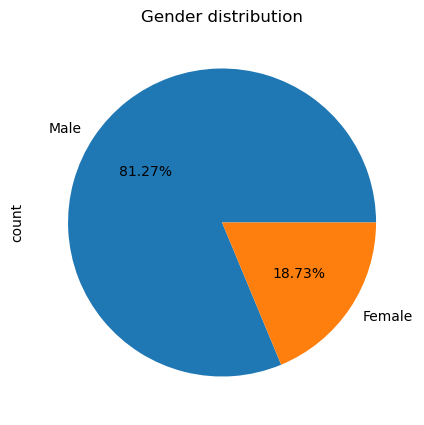

In [58]:
df["Gender"].value_counts().plot(
    kind = "pie",
    autopct="%2.2f%%", # shows percentages
    figsize=(5,5),     # size of plot
    title="Gender distribution"
)

In [59]:
df["Gender"].value_counts()

Gender
Male      499
Female    115
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Gender')

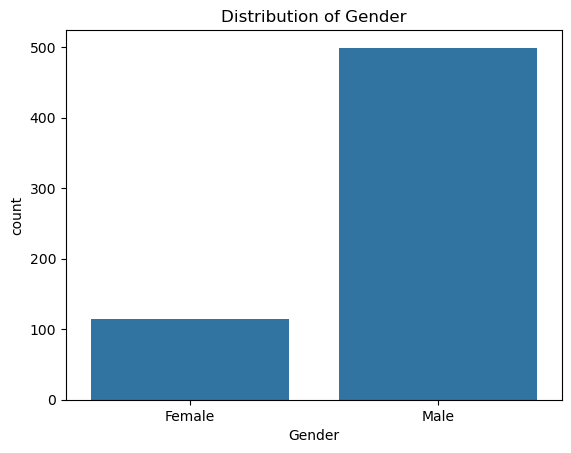

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df , x='Gender')
plt.title("Distribution of Gender")

**The dataset shows a strong gender imbalance, with male applicants accounting for approximately 81% of total loan applications, suggesting that loan demand is predominantly driven by men**

2. What proportion of applicants are Married vs Unmarried?

In [61]:
df["Married"].value_counts(dropna=False)

Married
Yes    399
No     215
Name: count, dtype: int64

In [62]:
df["Married"].value_counts(normalize=True)*100

Married
Yes    64.983713
No     35.016287
Name: proportion, dtype: float64

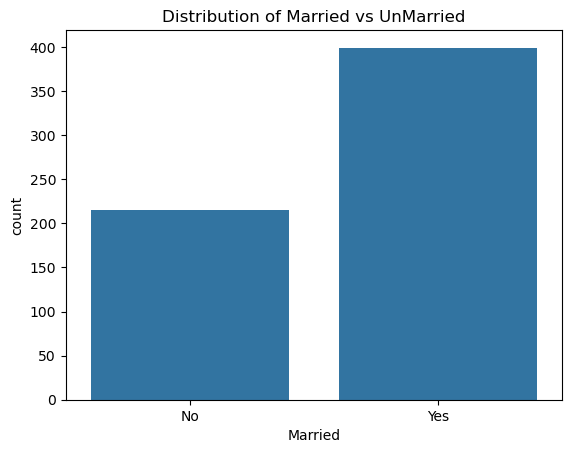

In [63]:
import seaborn as sns
sns.countplot(data=df, x="Married")
plt.title("Distribution of Married vs UnMarried")
plt.show()

**The majority of loan applicants (~64%) are married, indicating a higher representation of married individuals in the dataset compared to unmarried applicants.**

What percentage of applicants are Graduates vs Non-Graduates?

In [64]:
df["Education"].value_counts(dropna=False)

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [65]:
df["Education"].value_counts(normalize=True)*100

Education
Graduate        78.175896
Not Graduate    21.824104
Name: proportion, dtype: float64

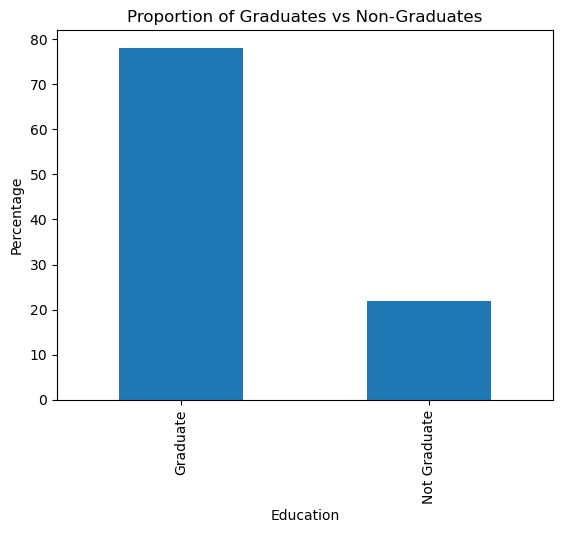

In [66]:
prop = df["Education"].value_counts(normalize=True)*100
prop.plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Proportion of Graduates vs Non-Graduates")
plt.show()

**Approxmitly 78% applicants are graudates, while 22% percentage are non-graudates, indicating that graduates form the majority of the applicant pool.**

What is the proportion of Self-Employed vs Salaried individuals ?

In [67]:
df["Self_Employed"].value_counts(dropna=False)

Self_Employed
No     523
Yes     91
Name: count, dtype: int64

In [68]:
df["Self_Employed"].value_counts(normalize=True)*100

Self_Employed
No     85.179153
Yes    14.820847
Name: proportion, dtype: float64

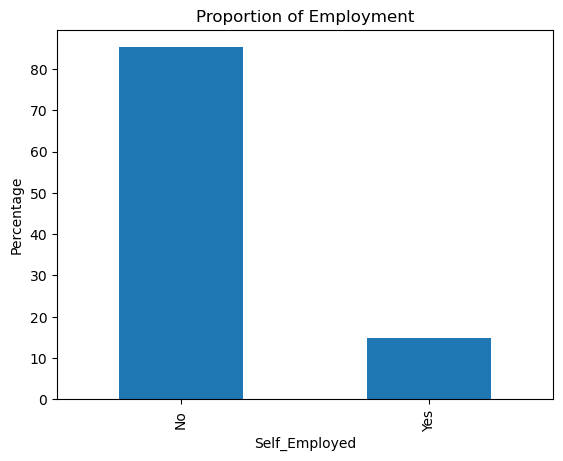

In [69]:
prop = df["Self_Employed"].value_counts(normalize=True)*100
prop.plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Proportion of Employment")
plt.show()

<Axes: title={'center': 'Distribution of Self Employed'}, ylabel='count'>

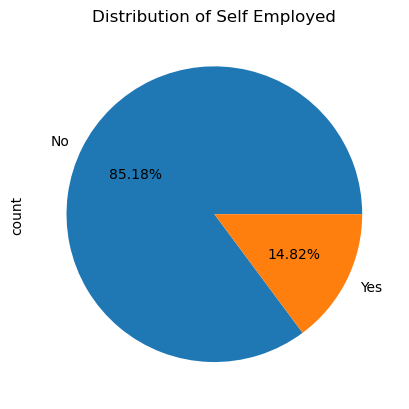

In [70]:
df["Self_Employed"].value_counts().plot(
    kind = "pie",
    autopct = "%2.2f%%",
    title = "Distribution of Self Employed"
)

Text(0.5, 1.0, 'Distribution of Employed')

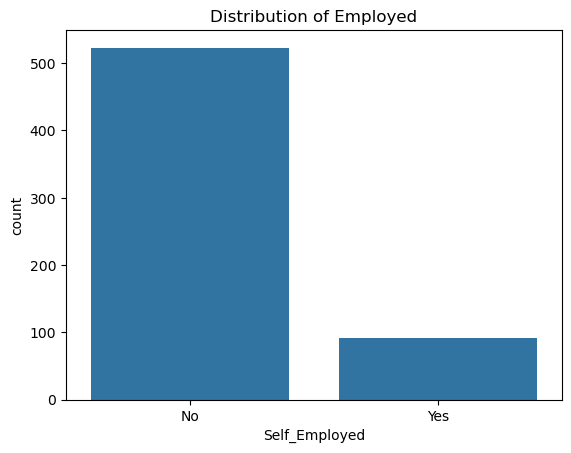

In [71]:
import seaborn as sns
sns.countplot(data=df, x="Self_Employed")
plt.title("Distribution of Employed")

**The majority of applicants (~85%) are not self-employed, whereas only about 15% are self-employed, showing a strong dominance of salaried or non-self-employed individuals in the dataset**

4. what is the average applicant income?

In [72]:
df["Applicant_Income"].mean()

np.float64(5403.459283387622)

  The Average applicant income is 5403.4592

5. how is the the applicant's income is distributed?

Text(0, 0.5, 'frequency')

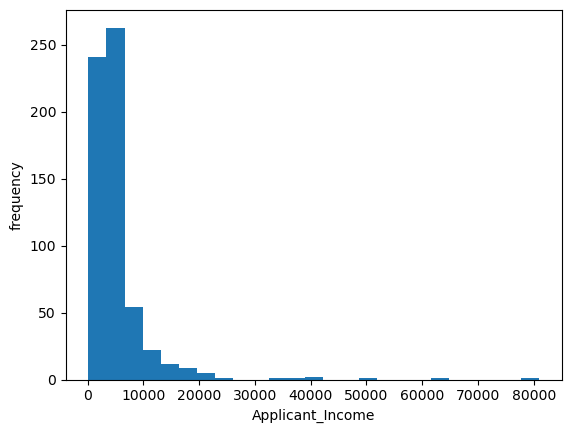

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(df["Applicant_Income"],bins=25)
plt.xlabel("Applicant_Income")
plt.ylabel("frequency")

<Axes: xlabel='Applicant_Income', ylabel='Count'>

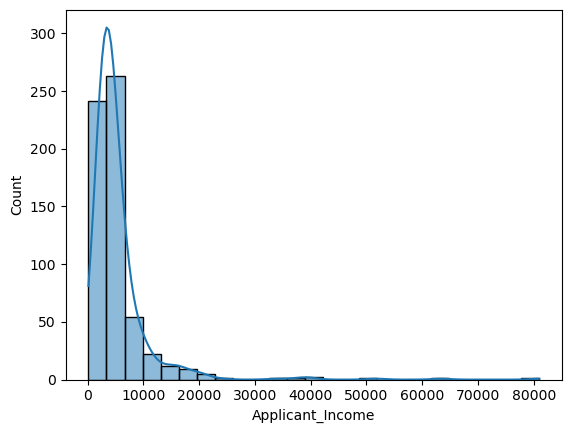

In [74]:
sns.histplot(df["Applicant_Income"],bins=25, kde=True)

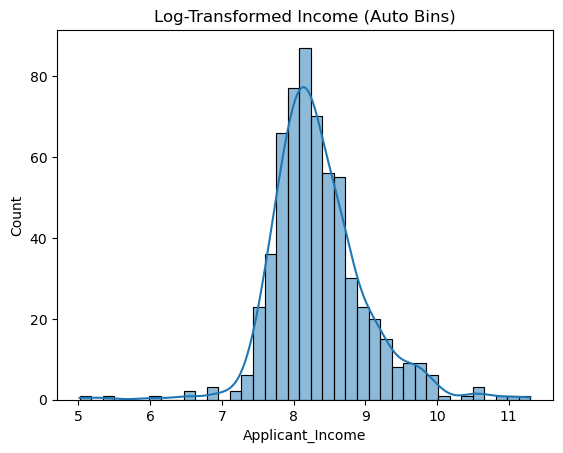

In [75]:
import numpy as np
sns.histplot(np.log1p(df["Applicant_Income"]), bins='auto', kde=True)
plt.title("Log-Transformed Income (Auto Bins)")
plt.show()

**Most of the applicants have relatively low to medium incomes, while few applicants earn substainly, creates a longer tail on the right tail. This positive skew suggests that the dataset contains outliers and that the mean income is likely higher than the median.**

6. How is the co applicant income is distributed?

Text(0, 0.5, 'frequency')

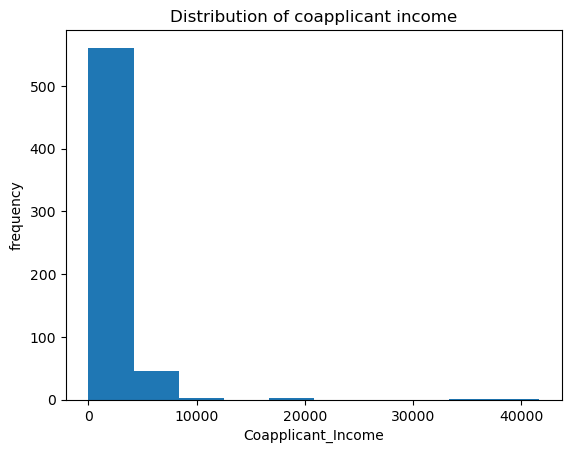

In [76]:
import matplotlib.pyplot as plt
plt.hist(df['Coapplicant_Income'])
plt.title("Distribution of coapplicant income")
plt.xlabel("Coapplicant_Income")
plt.ylabel("frequency")

Text(0, 0.5, 'frequency')

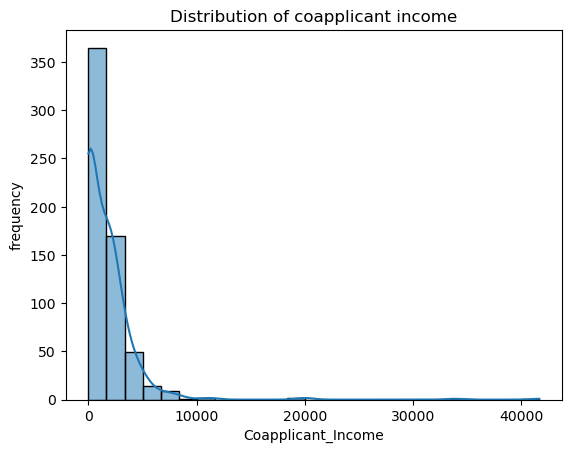

In [77]:
sns.histplot(df["Coapplicant_Income"], bins=25, kde=True)
plt.title("Distribution of coapplicant income")
plt.xlabel("Coapplicant_Income")
plt.ylabel("frequency")

**Most of the co-applicants have relatively low to medium incomes, while few applicants earn substainly, creates a longer tail on the right tail. This positive skew suggests that the dataset contains outliers and that the mean income is likely higher than the median.**

7. **List out the people who are having good credit history or how many people with good credit history?**

In [78]:
df["Credit_History"].value_counts(dropna=False)

Credit_History
1    522
0     92
Name: count, dtype: int64

In [79]:
df["Credit_History"].value_counts(normalize="index")*100

Credit_History
1    85.016287
0    14.983713
Name: proportion, dtype: float64

The 85% percent of applicants are having the good credit history.

8. How many applicants fall into each Dependents category (0,1,2,3+)?

In [80]:
df["Dependents"].value_counts(dropna=False).sort_index()

Dependents
0    351
1    102
2    110
4     51
Name: count, dtype: int64

**Bi-Varaint analysis**

What is the relationship between gender and loan approval status?

In [81]:
df.groupby("Gender")["Loan_Status"].value_counts()

Gender  Loan_Status
Female  Y               78
        N               37
Male    Y              344
        N              155
Name: count, dtype: int64

In [82]:
pd.crosstab(df["Gender"], df["Loan_Status"], normalize="index")*100

Loan_Status,N,Y
Gender,,
Female,32.173913,67.826087
Male,31.062124,68.937876


Text(0.5, 1.0, 'Loan approval status by Gender')

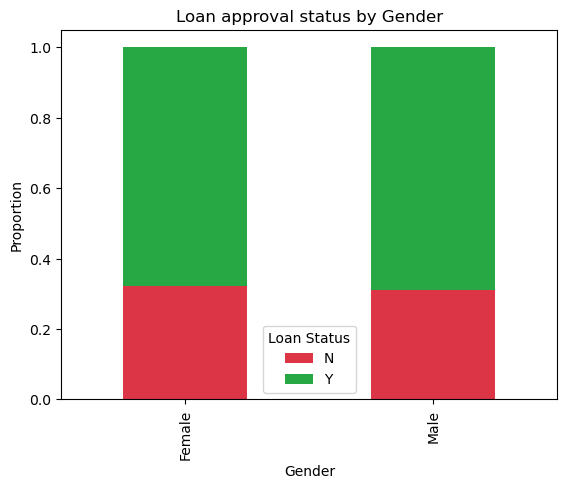

In [83]:
ax = pd.crosstab(df["Gender"],df["Loan_Status"], normalize="index").plot(kind="bar", stacked=True, color=["#DC3545","#28A745"])
ax.set_xlabel("Gender")
ax.set_ylabel("Proportion")
ax.legend(title = "Loan Status")
ax.set_title("Loan approval status by Gender")

**The loan approval rate for male is 68.5 and 67.5 for female and there is no difference in approval rate and gender alone won't be sufficent is determining loan approavl**

**Does education level (graduate vs non-graduate) influence loan approval?**

In [84]:
df.groupby("Education")["Loan_Status"].value_counts()

Education     Loan_Status
Graduate      Y              340
              N              140
Not Graduate  Y               82
              N               52
Name: count, dtype: int64

In [85]:
pd.crosstab(df["Education"], df["Loan_Status"], normalize="index")*100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


Text(0.5, 1.0, 'Loan approval status by Education')

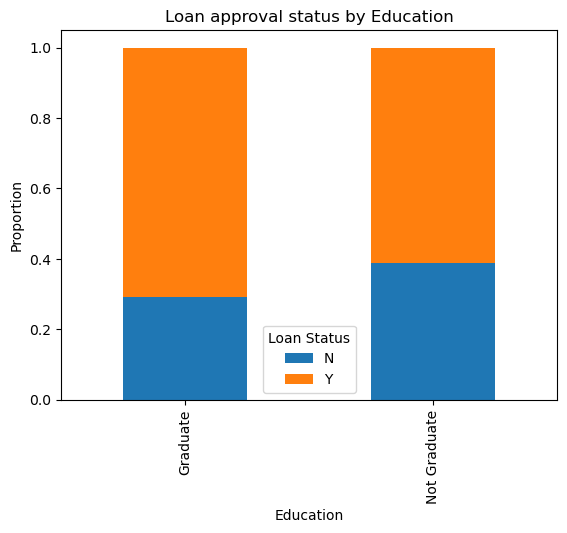

In [86]:
bx = pd.crosstab(df["Education"], df["Loan_Status"], normalize="index").plot(kind="bar", stacked=True)
bx.set_xlabel("Education")
bx.set_ylabel("Proportion")
bx.legend(title = "Loan Status")
bx.set_title("Loan approval status by Education")

**Loan approval rates are slightly higher for graduates (70.8%) compared to non-graduates (61.2%), showing a difference of around 10 percentage points. While graduates have a higher approval rate, the gap is relatively moderate, suggesting that education alone may not be a strong determining factor in loan approval**

**How does self-employment status impact loan approval rates?**

In [87]:
df.groupby("Self_Employed")["Loan_Status"].value_counts()

Self_Employed  Loan_Status
No             Y              360
               N              163
Yes            Y               62
               N               29
Name: count, dtype: int64

In [88]:
pd.crosstab(df["Self_Employed"], df["Loan_Status"], normalize="index")*100

Loan_Status,N,Y
Self_Employed,,
No,31.166348,68.833652
Yes,31.868132,68.131868


**The loan approval rate for Self Employed is 68.13 compared to applicants who are  not self employed (68.83), showing difference 0.1 suggesting the self_employment status is not a strong detemining factor in loan approval**

**Is there a relationship between applicant/co-applicant income and loan approval?**

Note: instead of checking on the single variable , it makes sense to use total_income and then apply box plot.

if there is higer income, there is a chance of high loan approval

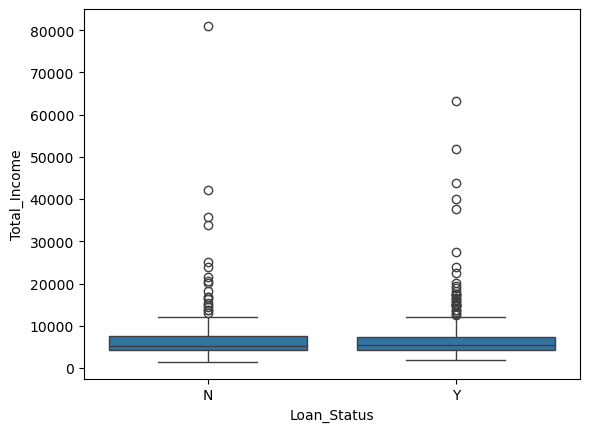

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
df["Total_Income"] = df["Applicant_Income"] + df ["Coapplicant_Income"]
sns.boxplot(x="Loan_Status", y="Total_Income", data=df)
plt.show()

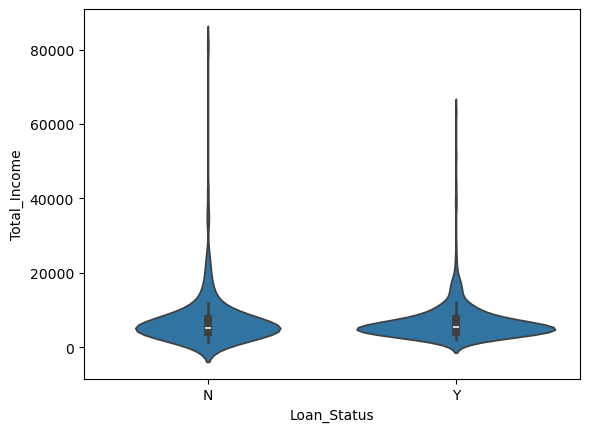

In [90]:
sns.violinplot(x="Loan_Status", y="Total_Income", data=df)
plt.show()

<Axes: xlabel='Total_Income', ylabel='Density'>

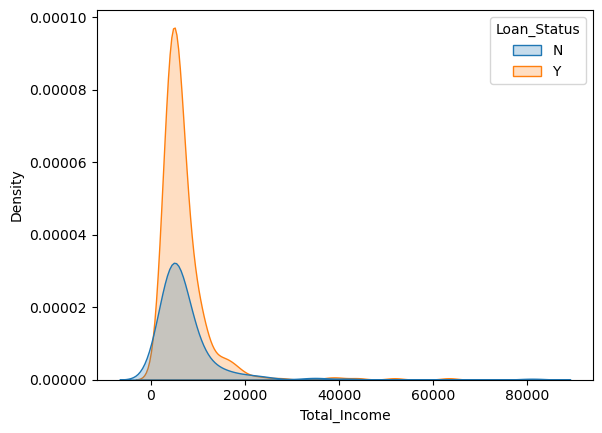

In [91]:
sns.kdeplot(data=df, x="Total_Income", hue="Loan_Status", fill=True)

In [92]:
df["Income_Bin"] = pd.qcut(df["Total_Income"], q=5)

In [93]:
pd.crosstab(df["Income_Bin"], df["Loan_Status"], normalize="index") * 100

Loan_Status,N,Y
Income_Bin,,
"(1441.999, 3812.6]",34.959350,65.040650
"(3812.6, 4807.4]",30.081301,69.918699
"(4807.4, 6042.6]",26.229508,73.770492
"(6042.6, 8334.0]",33.064516,66.935484
"(8334.0, 81000.0]",31.967213,68.032787


**Loan approval rates show a gradual increase with higher income levels. Applicants in the lower income group (1441–3812) have an approval rate of approximately 65%, while those in the higher income group (3812–4807) show a higher approval rate of around 70%. This indicates that higher income has a positive but limited impact on loan approval, suggesting that other factors also play a significant role**

In [94]:
df.groupby("Loan_Status")["Total_Income"].median()

Loan_Status
N    5289.5
Y    5439.0
Name: Total_Income, dtype: float64

**Medain incomes are nearly identical**

the median value of approved people is slightly more than people whose loan is not approved**

In [95]:
df.groupby("Loan_Status")["Total_Income"].mean()

Loan_Status
N    7323.885417
Y    6888.585118
Name: Total_Income, dtype: float64

**the average earning of loan approved people is slightly less than the people who's loan is not approved**

Note: Median make sense in terms of calcuating the salray instead of going for the average

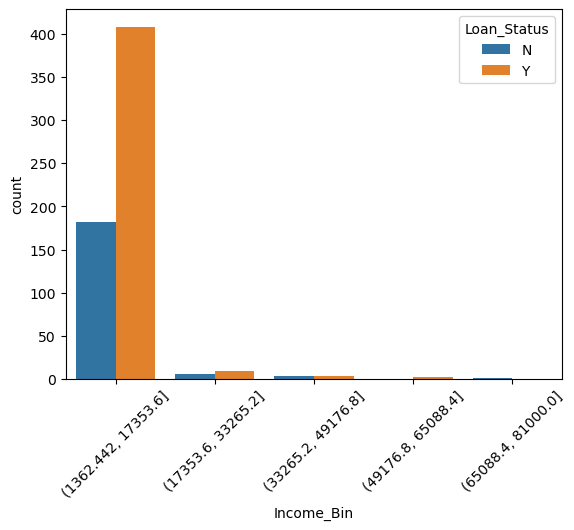

In [96]:
import seaborn as sns
df["Income_Bin"] = pd.cut(df["Total_Income"], bins=5)
sns.countplot(x="Income_Bin", hue="Loan_Status", data=df)
plt.xticks(rotation=45)
plt.show()

**How strongly does credit history impact loan approval?**

In [97]:
df["Credit_History"].value_counts(dropna=False)

Credit_History
1    522
0     92
Name: count, dtype: int64

In [98]:
pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index")*100

Loan_Status,N,Y
Credit_History,,
0,89.130435,10.869565
1,21.072797,78.927203


Text(0, 0.5, 'Count')

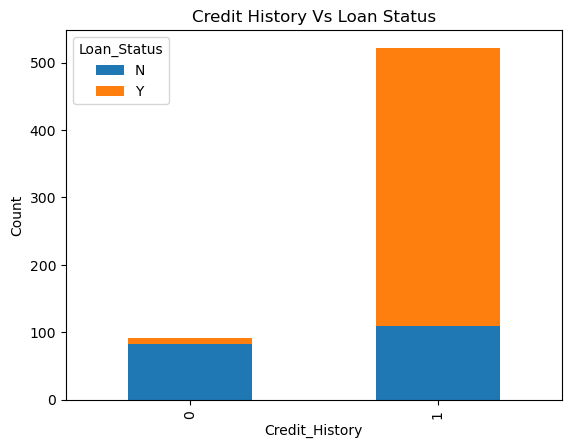

In [99]:
#using the stacked bar plot
import matplotlib.pyplot as plt
pd.crosstab(df["Credit_History"], df["Loan_Status"]).plot(kind="bar", stacked=True)
plt.title("Credit History Vs Loan Status")
plt.xlabel("Credit_History")
plt.ylabel("Count")

**The approval rate increases by nearly 7x for applicants with a good credit history, highlighting it as one of the most critical predictors in the loan approval process.**

**Are longer loan terms more likely to be approved?**

In [100]:
df["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
360    517
180     44
480     15
300     13
120     12
240      4
84       4
36       2
60       2
12       1
Name: count, dtype: int64

In [101]:
pd.crosstab(df["Loan_Amount_Term"], df["Loan_Status"], normalize="index") * 100

Loan_Status,N,Y
Loan_Amount_Term,,
12,0.000000,100.000000
36,100.000000,0.000000
60,0.000000,100.000000
84,25.000000,75.000000
120,33.333333,66.666667
180,34.090909,65.909091
240,25.000000,75.000000
300,38.461538,61.538462
360,29.980658,70.019342


<Axes: xlabel='Loan_Amount_Term'>

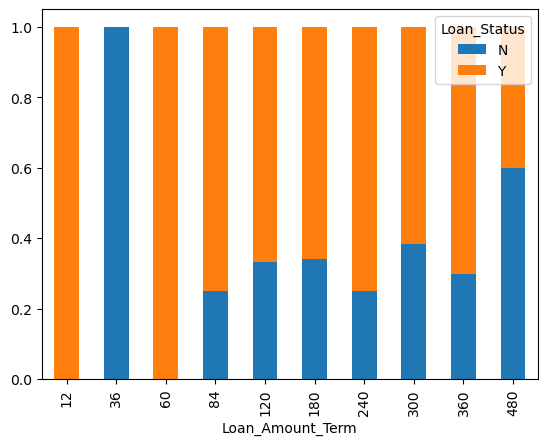

In [102]:
pd.crosstab(df["Loan_Amount_Term"], df["Loan_Status"], normalize="index")\
.plot(kind="bar", stacked=True)

In [103]:
ct = pd.crosstab(df["Loan_Amount_Term"], df["Loan_Status"])
print(ct)

Loan_Status         N    Y
Loan_Amount_Term          
12                  0    1
36                  2    0
60                  0    2
84                  1    3
120                 4    8
180                15   29
240                 1    3
300                 5    8
360               155  362
480                 9    6


**Loan approval rates remain relatively stable across most loan terms (120–360 months), generally ranging between 60% and 75%. While some longer terms like 240 and 360 months show slightly higher approval rates, the difference is not substantial. This suggests that loan term has a moderate to weak impact on approval decisions compared to stronger factors like credit history. Extreme values observed for very short or very long terms are likely due to low sample sizes and should not be overinterpreted.**

**Which area (Urban / Semiurban / Rural) has the highest approval rate?**

In [104]:
pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index")*100

Loan_Status,N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


In [105]:
pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index") \
  .mul(100).round(2) \
  .sort_values("Y", ascending=False)

Loan_Status,N,Y
Property_Area,,
Semiurban,23.18,76.82
Urban,34.16,65.84
Rural,38.55,61.45


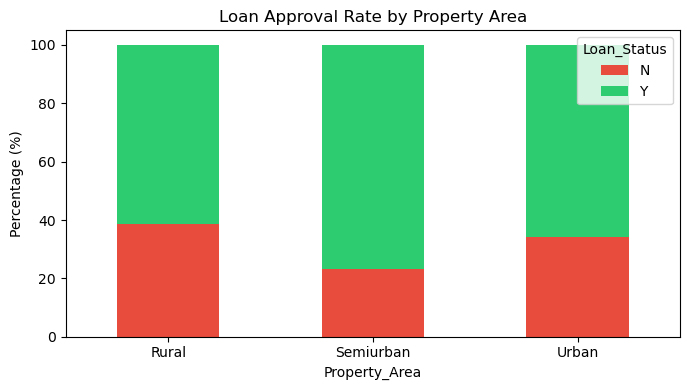

In [106]:
#.mul(100) so the y-axis shows 0–100% instead of 0.0–1.0
import matplotlib.pyplot as plt
import seaborn as sns
pcts = pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index").mul(100)
pcts.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], figsize=(7,4))
plt.title("Loan Approval Rate by Property Area")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Semiurban areas exhibit the highest loan approval rate (76.8%), significantly higher than Urban (65.8%) and Rural (~61.5%) areas. This suggests that geographic location influences approval outcomes, with Semiurban applicants potentially having a more favorable risk profile or balanced financial characteristics.**

**Multivariate Analysis**

How does credit history + income together affect approval?

Does education + income influence approval?

Are high-income applicants without credit history still rejected?

Does property area + income impact approval?

How does credit history + income together affect approval?

**How does credit history + income together affect approval?**

In [107]:
df["Applicant_Income"].describe()

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: Applicant_Income, dtype: float64

<Axes: ylabel='Frequency'>

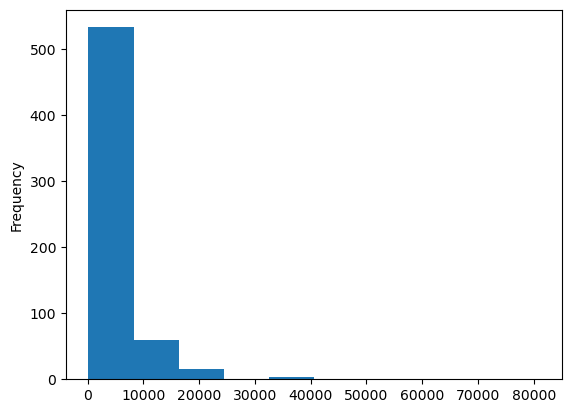

In [108]:
df["Applicant_Income"].plot(kind="hist")

In [109]:
df["Income_Bin"] = pd.qcut(
    df["Applicant_Income"],
    q=3,
    labels=["Low", "Medium", "High"]
)

Note: using qcut hepls you with binning i.e is Splits it into equal-sized groups (quantiles)

Divide data into:

3 equal parts (each ~33% of data)

| Method      | Logic                            | When to Use         |
| ----------- | -------------------------------- | ------------------- |
| `pd.cut()`  | Equal **range width**            | Normal distribution |
| `pd.qcut()` | Equal **number of observations** | Skewed data ✅       |


In [110]:
df["Income_Bin"].value_counts()

Income_Bin
Low       207
High      205
Medium    202
Name: count, dtype: int64

In [111]:
pd.crosstab([df["Income_Bin"],df["Credit_History"]], df["Loan_Status"], normalize="index")*100

Loan_Status                        N          Y
Income_Bin Credit_History                      
Low        0               94.285714   5.714286
           1               17.441860  82.558140
Medium     0               85.185185  14.814815
           1               23.428571  76.571429
High       0               86.666667  13.333333
           1               22.285714  77.714286

<Axes: ylabel='Income_Bin,Credit_History'>

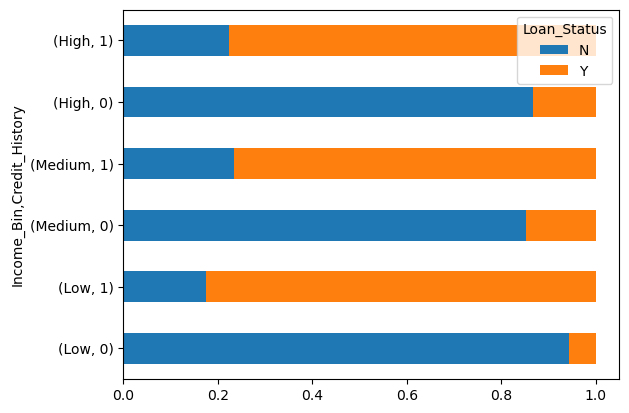

In [112]:
pd.crosstab([df["Income_Bin"],df["Credit_History"]], df["Loan_Status"], normalize="index").plot(kind="barh", stacked=True)

**Loan approval is driven primarily by credit history rather than income. Even low-income applicants with good credit history have high approval rates, while high-income applicants with poor credit history are mostly rejected.**

**Does education + income influence approval?**

In [113]:
df["Income_Bin"] = pd.qcut(
    df["Applicant_Income"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [114]:
ct = pd.crosstab([df["Income_Bin"],df["Education"]], df["Loan_Status"], normalize="index")*100
ct

Loan_Status                      N          Y
Income_Bin Education                         
Low        Graduate      25.850340  74.149660
           Not Graduate  41.666667  58.333333
Medium     Graduate      31.125828  68.874172
           Not Graduate  33.333333  66.666667
High       Graduate      30.219780  69.780220
           Not Graduate  43.478261  56.521739

<Axes: ylabel='Income_Bin,Education'>

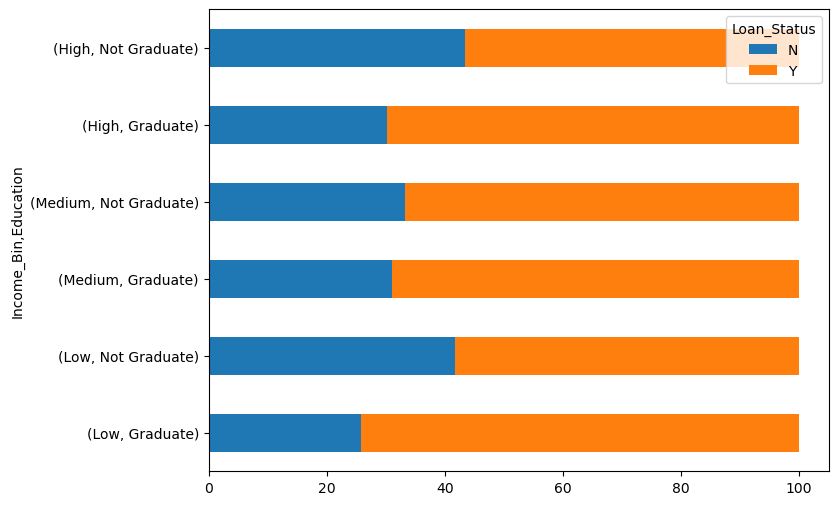

In [115]:
ct.plot(kind="barh", stacked=True, figsize=(8,6))

While income generally influences loan approval, education appears to have a strong positive impact, as graduates exhibit higher approval rates across all income groups, with low-income graduates achieving the highest approval (~74%). This suggests that education may compensate for lower income in loan decisions.

**Are high-income applicants without credit history still rejected?**

In [116]:
pd.crosstab([ df["Income_Bin"], df["Credit_History"]], df["Loan_Status"], normalize="index")*100

Loan_Status                        N          Y
Income_Bin Credit_History                      
Low        0               94.285714   5.714286
           1               17.441860  82.558140
Medium     0               85.185185  14.814815
           1               23.428571  76.571429
High       0               86.666667  13.333333
           1               22.285714  77.714286

**Yes, high-income applicants without credit history are still mostly rejected (~86%), indicating that credit history is a more critical factor than income in loan approval.**